# RNNs trained on Sequential Dynamics - Demo

Here, we train RNNs on sequential time series data. RNN is implemented in continuous time as 

$$\dot{h} = h_t + \tau\phi(W_{hh}h_t + W_{ih}x_t),$$

where $\tau$ is a learnable time step.

<p align="center">
<img class="center" src="../figures/student_network.png" height="300"> </p>

### Setup

In [1]:
from pathlib import Path
import sys
REPO_ROOT = Path.cwd().parent
sys.path.append(str(REPO_ROOT))
import torch as torch
import matplotlib.pyplot as plt
import torch.nn.functional as F
from src.data.generation import GaussianPulseDataset
from src.utils.plotting import plot_interm_fig_plt
from src.models.rnn import SequentialRNN
from IPython.display import clear_output

# reproducibility
torch.use_deterministic_algorithms(True)
torch.manual_seed(1234)

### Create Dataset from Teacher and train Student

In [2]:
n_neurons = hidden_size = 8
seq_length = 50
n_samples = 500
batch_size = 16
input_size = 1
n_epochs = 5000

# create dataset and model
gps = GaussianPulseDataset(seq_length=seq_length, n_pulse=n_neurons, n_samples = n_samples, sequence_type='rnn')
loader = torch.utils.data.DataLoader(gps, batch_size=batch_size, shuffle=True)
model = SequentialRNN(input_size, hidden_size)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=n_epochs,eta_min=1e-5)

# for storing training progress and plotting
losses = []
test_sample = gps[0]


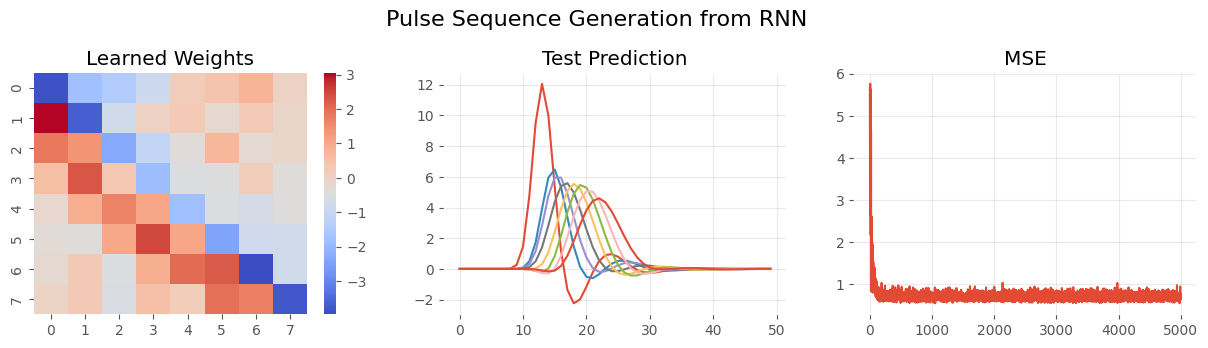

In [3]:
# training loop
for _ in range(n_epochs):

    model.train()
    for (X, y) in loader:
        optimizer.zero_grad()
        y_pred = model(X)
        mask = y > 0
        anti_mask = y == 0
        l2_regularization = torch.linalg.norm(model.W_hh.weight, ord=2)
        loss = F.mse_loss(y[mask],y_pred[mask]) + 2*F.mse_loss(y[anti_mask],y_pred[anti_mask]) + 0.1*l2_regularization
        loss.backward()
        optimizer.step()
    scheduler.step()
    losses.append(loss.item())

    # plot intermediate results
    with torch.no_grad():
        test_outp = model(torch.reshape(test_sample[0], (1,seq_length,1)).float()).squeeze(0).detach().numpy()
    
    clear_output(wait=True)   
    
    fig = plot_interm_fig_plt(test_outp, torch.tensor(losses).detach().numpy(), model.W_hh.weight.detach().numpy())

    display(fig);              
    plt.close(fig)            